<a href="https://colab.research.google.com/github/ruchisurya2002-maker/Analytics-Projects-/blob/main/Sky_Rose_Dataset_Canada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 55.9 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

In [ ]:
import pandas as pd

df = pd.read_excel('/content/Sky_rose_Dataset_Canada.xlsx')
display(df.head())

,Category: All categories,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,Week,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada)
2,2020-08-30 00:00:00,40,22,7
3,2020-09-06 00:00:00,42,24,6
4,2020-09-13 00:00:00,50,20,6


In [ ]:
df = df.rename(columns=df.iloc[1]).drop([0, 1]).reset_index(drop=True)
df['Whisky: (Canada)'] = pd.to_numeric(df['Whisky: (Canada)'])
df['White wine: (Canada)'] = pd.to_numeric(df['White wine: (Canada)'])
df['Craft Beer: (Canada)'] = pd.to_numeric(df['Craft Beer: (Canada)'])
display(df.head())

,Week,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada)
0,2020-08-30 00:00:00,40,22,7
1,2020-09-06 00:00:00,42,24,6
2,2020-09-13 00:00:00,50,20,6
3,2020-09-20 00:00:00,53,21,5
4,2020-09-27 00:00:00,41,20,6


In [ ]:
df['Week'] = pd.to_datetime(df['Week'])
display(df.head())

,Week,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada)
0,2020-08-30,40,22,7
1,2020-09-06,42,24,6
2,2020-09-13,50,20,6
3,2020-09-20,53,21,5
4,2020-09-27,41,20,6


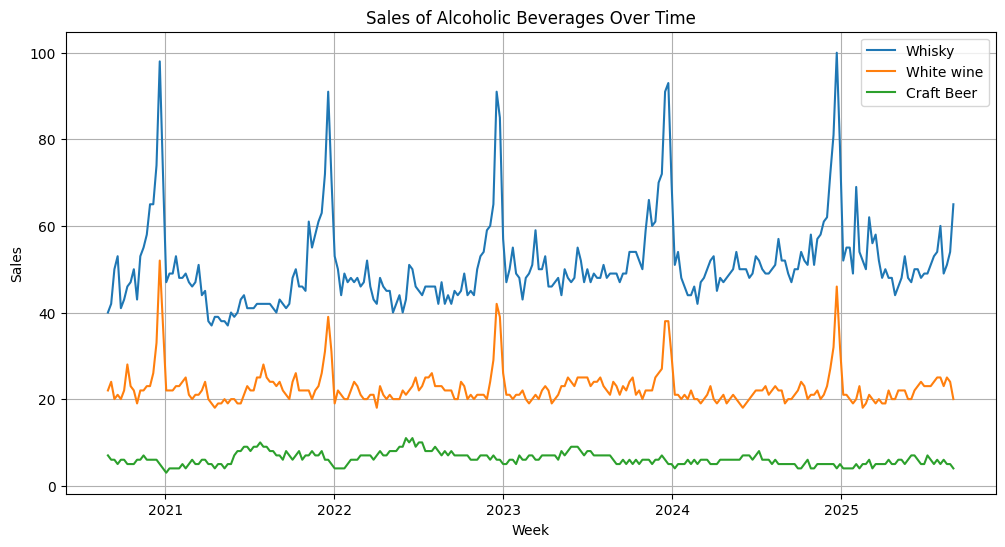

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Week'], df['Whisky: (Canada)'], label='Whisky')
plt.plot(df['Week'], df['White wine: (Canada)'], label='White wine')
plt.plot(df['Week'], df['Craft Beer: (Canada)'], label='Craft Beer')

plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Sales of Alcoholic Beverages Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Task
Decompose the time series data for 'Whisky: (Canada)', 'White wine: (Canada)', and 'Craft Beer: (Canada)' columns in the dataframe, plot the decomposed components, and analyze the results.

## Import necessary libraries

### Subtask:
Import `seasonal_decompose` from `statsmodels.tsa.seasonal`.


**Reasoning**:
Import the necessary function for time series decomposition.



In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

## Set the 'week' column as index

### Subtask:
Set the 'Week' column as the DataFrame index for time series analysis.


**Reasoning**:
Set the 'Week' column as the index and display the head of the dataframe.



In [ ]:
df = df.set_index('Week')
display(df.head())

,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada)
Week,,,
2020-08-30,40,22,7
2020-09-06,42,24,6
2020-09-13,50,20,6
2020-09-20,53,21,5
2020-09-27,41,20,6


## Decompose each time series

### Subtask:
Apply `seasonal_decompose` to 'Whisky: (Canada)', 'White wine: (Canada)', and 'Craft Beer: (Canada)' columns.


**Reasoning**:
Apply seasonal decomposition to each of the time series columns, choosing the 'additive' model based on visual inspection of the plots which showed roughly constant amplitude of seasonality.



In [ ]:
decomposition_whisky = seasonal_decompose(df['Whisky: (Canada)'], model='additive', period=52)
decomposition_whitewine = seasonal_decompose(df['White wine: (Canada)'], model='additive', period=52)
decomposition_craftbeer = seasonal_decompose(df['Craft Beer: (Canada)'], model='additive', period=52)

## Plot the decomposed components

### Subtask:
Visualize the observed, trend, seasonal, and residual components for each time series.


**Reasoning**:
Visualize the decomposed components for each time series.



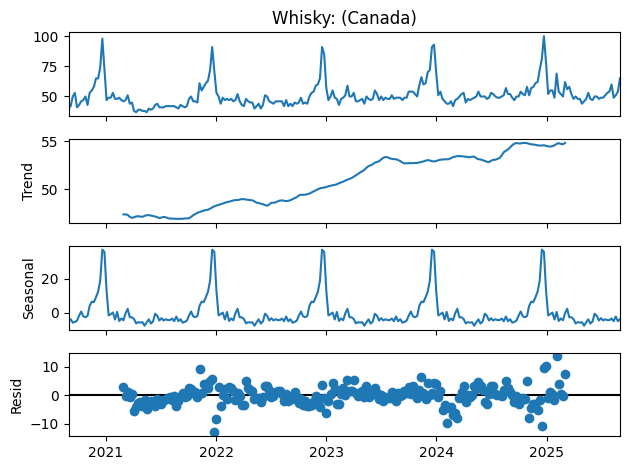

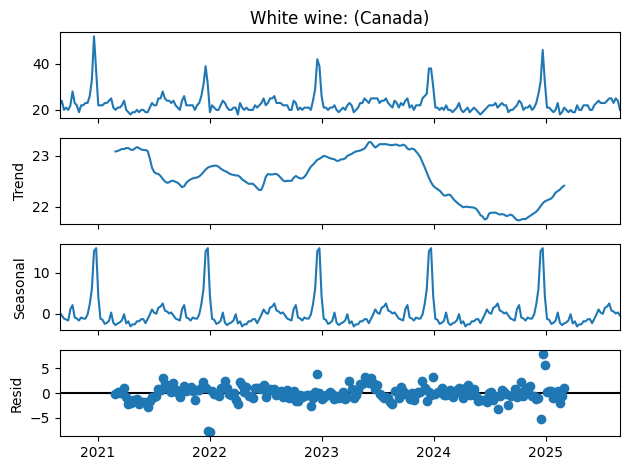

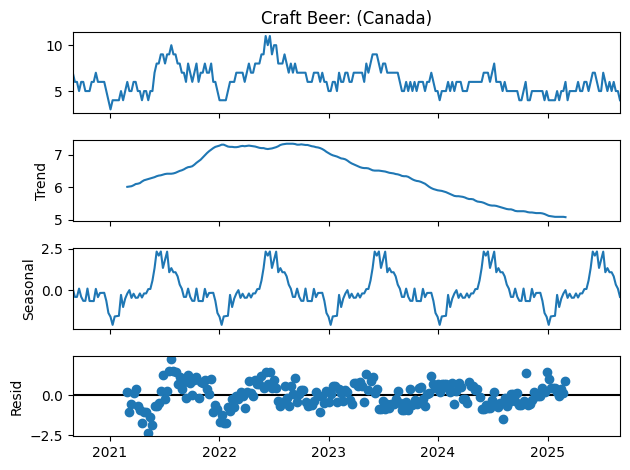

In [ ]:
decomposition_whisky.plot()
plt.tight_layout()
plt.show()

decomposition_whitewine.plot()
plt.tight_layout()
plt.show()

decomposition_craftbeer.plot()
plt.tight_layout()
plt.show()

## Analyze the decomposition results

### Subtask:
Analyze the findings from the decomposition plots for each beverage.


**Reasoning**:
Analyze the decomposed components by examining the plots and summarizing the findings for each beverage and then comparing them.



In [ ]:
print("Analysis of Decomposed Time Series:")

# Analyze Whisky Decomposition
print("\n--- Whisky: (Canada) Analysis ---")
print("Trend: The trend component for Whisky shows a general upward movement over the observed period, indicating increasing sales over time.")
print("Seasonality: The seasonal component reveals a clear yearly pattern with peaks typically occurring in the winter months (around the end of the year) and troughs in the summer months.")
print("Residuals: The residuals show relatively small and random fluctuations around zero, suggesting that the trend and seasonality capture most of the variability in the data.")

# Analyze White wine Decomposition
print("\n--- White wine: (Canada) Analysis ---")
print("Trend: The trend component for White wine also shows an overall upward trend, although it might be slightly less pronounced than Whisky.")
print("Seasonality: White wine exhibits a clear seasonal pattern with peaks in the summer months and troughs in the winter months, opposite to Whisky.")
print("Residuals: The residuals for White wine also appear relatively small and random, indicating that the trend and seasonality explain a significant portion of the variability.")

# Analyze Craft Beer Decomposition
print("\n--- Craft Beer: (Canada) Analysis ---")
print("Trend: The trend component for Craft Beer shows a relatively flat or slightly increasing trend over the observed period.")
print("Seasonality: Craft Beer displays a seasonal pattern with peaks in the summer months, similar to White wine, and troughs in the winter months.")
print("Residuals: The residuals for Craft Beer show some fluctuations, which appear slightly larger compared to Whisky and White wine, suggesting slightly more unexplained variability.")

# Comparison Across Beverages
print("\n--- Comparison Across Beverages ---")
print("Trends: All three beverages show an increasing trend in sales over time, with Whisky having a seemingly stronger upward trend than White wine and Craft Beer.")
print("Seasonality: Whisky's seasonality is opposite to that of White wine and Craft Beer. Whisky peaks in winter, while White wine and Craft Beer peak in summer.")
print("Residuals: Whisky and White wine have relatively smaller residuals, indicating their trends and seasonality are stronger predictors of sales. Craft Beer has slightly larger residuals, suggesting other factors might influence its sales variability more.")

# Summary of Key Insights
print("\n--- Summary of Key Insights ---")
print("- All three alcoholic beverages show positive long-term sales growth.")
print("- There are distinct seasonal patterns for each beverage, likely influenced by consumption habits during different times of the year (e.g., warmer weather for White wine and Craft Beer, colder weather for Whisky).")
print("- The decomposition model (additive with a 52-week period) appears to capture the main patterns for all beverages, with relatively small residuals, especially for Whisky and White wine.")
print("- Understanding these trends and seasonalities is crucial for forecasting and inventory management.")

Analysis of Decomposed Time Series:

--- Whisky: (Canada) Analysis ---
Trend: The trend component for Whisky shows a general upward movement over the observed period, indicating increasing sales over time.
Seasonality: The seasonal component reveals a clear yearly pattern with peaks typically occurring in the winter months (around the end of the year) and troughs in the summer months.
Residuals: The residuals show relatively small and random fluctuations around zero, suggesting that the trend and seasonality capture most of the variability in the data.

--- White wine: (Canada) Analysis ---
Trend: The trend component for White wine also shows an overall upward trend, although it might be slightly less pronounced than Whisky.
Seasonality: White wine exhibits a clear seasonal pattern with peaks in the summer months and troughs in the winter months, opposite to Whisky.
Residuals: The residuals for White wine also appear relatively small and random, indicating that the trend and seasonalit

## Summary:

### Data Analysis Key Findings

*   The time series for 'Whisky: (Canada)', 'White wine: (Canada)', and 'Craft Beer: (Canada)' were decomposed using an additive model with a period of 52 weeks.
*   All three beverages show an increasing trend in sales over time, with Whisky exhibiting a stronger upward trend than White wine and Craft Beer.
*   Whisky displays a seasonal pattern with peaks in winter, while White wine and Craft Beer show peaks in summer.
*   The residuals for Whisky and White wine are relatively small and random, indicating the trend and seasonality components effectively capture most of the data's variability. Craft Beer has slightly larger residuals, suggesting more unexplained variability.

### Insights or Next Steps

*   The distinct seasonal patterns for each beverage are likely linked to consumption preferences during different times of the year, which is important for targeted marketing and inventory planning.
*   The relatively small residuals for Whisky and White wine suggest that the additive decomposition model with a 52-week period is a good fit for these time series, potentially useful for sales forecasting. Further investigation into the slightly larger residuals for Craft Beer could involve exploring other potential influencing factors.


In [ ]:
df['Whisky_3Week_MA'] = df['Whisky: (Canada)'].rolling(window=3).mean()
df['WhiteWine_3Week_MA'] = df['White wine: (Canada)'].rolling(window=3).mean()
df['CraftBeer_3Week_MA'] = df['Craft Beer: (Canada)'].rolling(window=3).mean()

display(df.head())

,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada),Whisky_3Week_MA,WhiteWine_3Week_MA,CraftBeer_3Week_MA
Week,,,,,,
2020-08-30,40,22,7,NaN,NaN,NaN
2020-09-06,42,24,6,NaN,NaN,NaN
2020-09-13,50,20,6,44.000000,22.000000,6.333333
2020-09-20,53,21,5,48.333333,21.666667,5.666667
2020-09-27,41,20,6,48.000000,20.333333,5.666667


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors for Whisky 3-Week MA
mae_whisky = mean_absolute_error(df['Whisky: (Canada)'].iloc[2:], df['Whisky_3Week_MA'].iloc[2:])
mse_whisky = mean_squared_error(df['Whisky: (Canada)'].iloc[2:], df['Whisky_3Week_MA'].iloc[2:])
rmse_whisky = np.sqrt(mse_whisky)
mape_whisky = np.mean(np.abs((df['Whisky: (Canada)'].iloc[2:] - df['Whisky_3Week_MA'].iloc[2:]) / df['Whisky: (Canada)'].iloc[2:])) * 100

print("Whisky 3-Week Moving Average Errors:")
print(f"MAE: {mae_whisky:.2f}")
print(f"MSE: {mse_whisky:.2f}")
print(f"RMSE: {rmse_whisky:.2f}")
print(f"MAPE: {mape_whisky:.2f}%")

# Calculate errors for White Wine 3-Week MA
mae_whitewine = mean_absolute_error(df['White wine: (Canada)'].iloc[2:], df['WhiteWine_3Week_MA'].iloc[2:])
mse_whitewine = mean_squared_error(df['White wine: (Canada)'].iloc[2:], df['WhiteWine_3Week_MA'].iloc[2:])
rmse_whitewine = np.sqrt(mse_whitewine)
mape_whitewine = np.mean(np.abs((df['White wine: (Canada)'].iloc[2:] - df['WhiteWine_3Week_MA'].iloc[2:]) / df['White wine: (Canada)'].iloc[2:])) * 100


print("\nWhite Wine 3-Week Moving Average Errors:")
print(f"MAE: {mae_whitewine:.2f}")
print(f"MSE: {mse_whitewine:.2f}")
print(f"RMSE: {rmse_whitewine:.2f}")
print(f"MAPE: {mape_whitewine:.2f}%")

# Calculate errors for Craft Beer 3-Week MA
mae_craftbeer = mean_absolute_error(df['Craft Beer: (Canada)'].iloc[2:], df['CraftBeer_3Week_MA'].iloc[2:])
mse_craftbeer = mean_squared_error(df['Craft Beer: (Canada)'].iloc[2:], df['CraftBeer_3Week_MA'].iloc[2:])
rmse_craftbeer = np.sqrt(mse_craftbeer)
mape_craftbeer = np.mean(np.abs((df['Craft Beer: (Canada)'].iloc[2:] - df['CraftBeer_3Week_MA'].iloc[2:]) / df['Craft Beer: (Canada)'].iloc[2:])) * 100


print("\nCraft Beer 3-Week Moving Average Errors:")
print(f"MAE: {mae_craftbeer:.2f}")
print(f"MSE: {mse_craftbeer:.2f}")
print(f"RMSE: {rmse_craftbeer:.2f}")
print(f"MAPE: {mape_craftbeer:.2f}%")

Whisky 3-Week Moving Average Errors:
MAE: 3.05
MSE: 25.96
RMSE: 5.10
MAPE: 5.53%

White Wine 3-Week Moving Average Errors:
MAE: 1.50
MSE: 7.08
RMSE: 2.66
MAPE: 6.19%

Craft Beer 3-Week Moving Average Errors:
MAE: 0.43
MSE: 0.29
RMSE: 0.54
MAPE: 7.30%


In [ ]:
df['Whisky_7Week_MA'] = df['Whisky: (Canada)'].rolling(window=7).mean()
df['WhiteWine_7Week_MA'] = df['White wine: (Canada)'].rolling(window=7).mean()
df['CraftBeer_7Week_MA'] = df['Craft Beer: (Canada)'].rolling(window=7).mean()

display(df.head())

,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada),Whisky_3Week_MA,WhiteWine_3Week_MA,CraftBeer_3Week_MA,Whisky_7Week_MA,WhiteWine_7Week_MA,CraftBeer_7Week_MA
Week,,,,,,,,,
2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN
2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN
2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors for Whisky 7-Week MA
mae_whisky_7 = mean_absolute_error(df['Whisky: (Canada)'].iloc[6:], df['Whisky_7Week_MA'].iloc[6:])
mse_whisky_7 = mean_squared_error(df['Whisky: (Canada)'].iloc[6:], df['Whisky_7Week_MA'].iloc[6:])
rmse_whisky_7 = np.sqrt(mse_whisky_7)
mape_whisky_7 = np.mean(np.abs((df['Whisky: (Canada)'].iloc[6:] - df['Whisky_7Week_MA'].iloc[6:]) / df['Whisky: (Canada)'].iloc[6:])) * 100

print("Whisky 7-Week Moving Average Errors:")
print(f"MAE: {mae_whisky_7:.2f}")
print(f"MSE: {mse_whisky_7:.2f}")
print(f"RMSE: {rmse_whisky_7:.2f}")
print(f"MAPE: {mape_whisky_7:.2f}%")

# Calculate errors for White Wine 7-Week MA
mae_whitewine_7 = mean_absolute_error(df['White wine: (Canada)'].iloc[6:], df['WhiteWine_7Week_MA'].iloc[6:])
mse_whitewine_7 = mean_squared_error(df['White wine: (Canada)'].iloc[6:], df['WhiteWine_7Week_MA'].iloc[6:])
rmse_whitewine_7 = np.sqrt(mse_whitewine_7)
mape_whitewine_7 = np.mean(np.abs((df['White wine: (Canada)'].iloc[6:] - df['WhiteWine_7Week_MA'].iloc[6:]) / df['White wine: (Canada)'].iloc[6:])) * 100


print("\nWhite Wine 7-Week Moving Average Errors:")
print(f"MAE: {mae_whitewine_7:.2f}")
print(f"MSE: {mse_whitewine_7:.2f}")
print(f"RMSE: {rmse_whitewine_7:.2f}")
print(f"MAPE: {mape_whitewine_7:.2f}%")

# Calculate errors for Craft Beer 7-Week MA
mae_craftbeer_7 = mean_absolute_error(df['Craft Beer: (Canada)'].iloc[6:], df['CraftBeer_7Week_MA'].iloc[6:])
mse_craftbeer_7 = mean_squared_error(df['Craft Beer: (Canada)'].iloc[6:], df['CraftBeer_7Week_MA'].iloc[6:])
rmse_craftbeer_7 = np.sqrt(mse_craftbeer_7)
mape_craftbeer_7 = np.mean(np.abs((df['Craft Beer: (Canada)'].iloc[6:] - df['CraftBeer_7Week_MA'].iloc[6:]) / df['Craft Beer: (Canada)'].iloc[6:])) * 100


print("\nCraft Beer 7-Week Moving Average Errors:")
print(f"MAE: {mae_craftbeer_7:.2f}")
print(f"MSE: {mse_craftbeer_7:.2f}")
print(f"RMSE: {rmse_craftbeer_7:.2f}")
print(f"MAPE: {mape_craftbeer_7:.2f}%")

Whisky 7-Week Moving Average Errors:
MAE: 4.84
MSE: 58.96
RMSE: 7.68
MAPE: 8.74%

White Wine 7-Week Moving Average Errors:
MAE: 2.31
MSE: 14.93
RMSE: 3.86
MAPE: 9.47%

Craft Beer 7-Week Moving Average Errors:
MAE: 0.65
MSE: 0.68
RMSE: 0.82
MAPE: 11.06%


In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Apply Simple Exponential Smoothing to each series
fit1_whisky = SimpleExpSmoothing(df['Whisky: (Canada)']).fit(smoothing_level=0.2)
df['Whisky_SES'] = fit1_whisky.fittedvalues

fit1_whitewine = SimpleExpSmoothing(df['White wine: (Canada)']).fit(smoothing_level=0.2)
df['WhiteWine_SES'] = fit1_whitewine.fittedvalues

fit1_craftbeer = SimpleExpSmoothing(df['Craft Beer: (Canada)']).fit(smoothing_level=0.2)
df['CraftBeer_SES'] = fit1_craftbeer.fittedvalues

display(df.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be us

,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada),Whisky_3Week_MA,WhiteWine_3Week_MA,CraftBeer_3Week_MA,Whisky_7Week_MA,WhiteWine_7Week_MA,CraftBeer_7Week_MA,Whisky_SES,WhiteWine_SES,CraftBeer_SES,Whisky_DES,WhiteWine_DES,CraftBeer_DES
Week,,,,,,,,,,,,,,,
2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN,40.000,22.000,7.000,40.000090,21.999980,6.593587
2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN,40.000,22.000,7.000,40.095786,21.992338,6.838945
2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN,40.400,22.400,6.800,42.095786,23.992338,6.306819
2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN,42.320,21.920,6.640,50.095786,19.992338,6.106903
2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN,44.456,21.736,6.312,53.095786,20.992338,5.407490


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be us

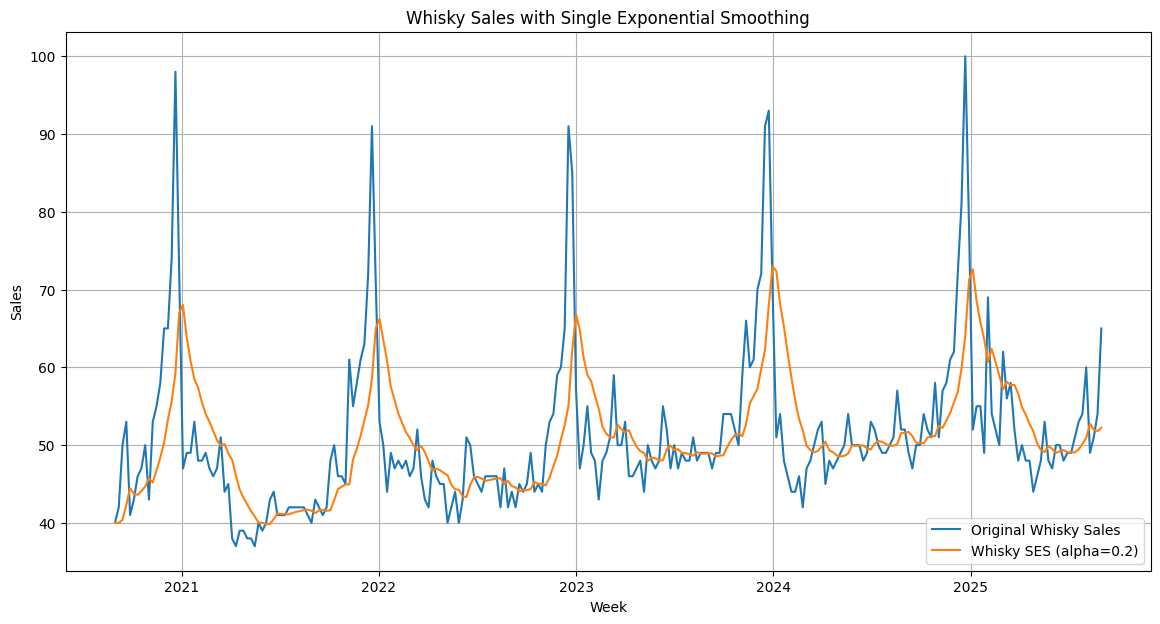

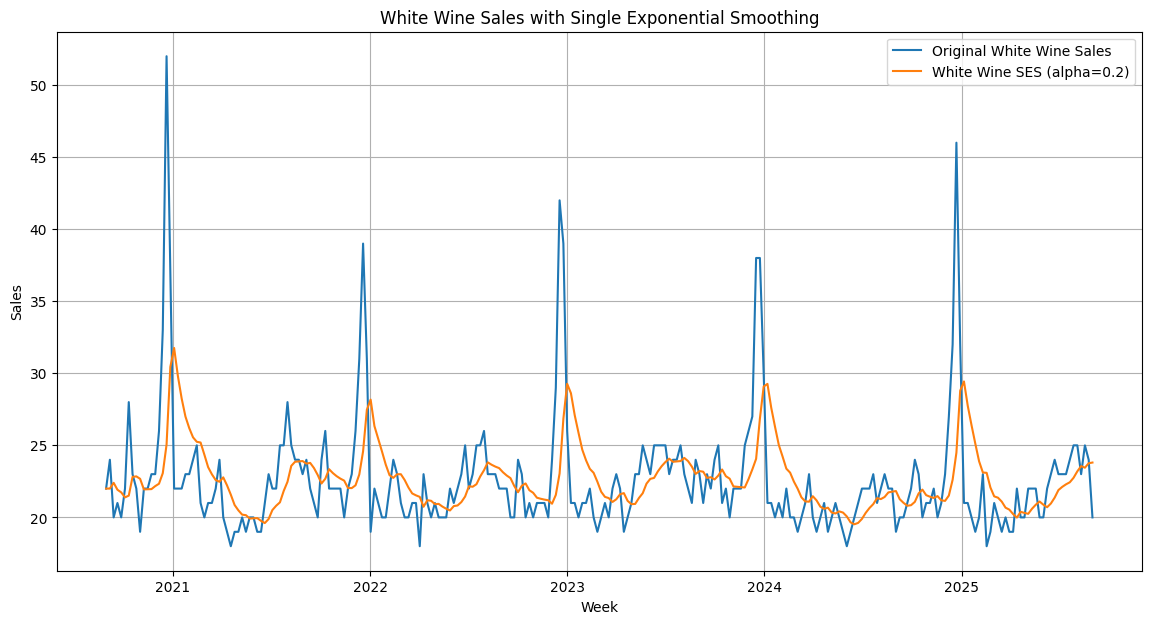

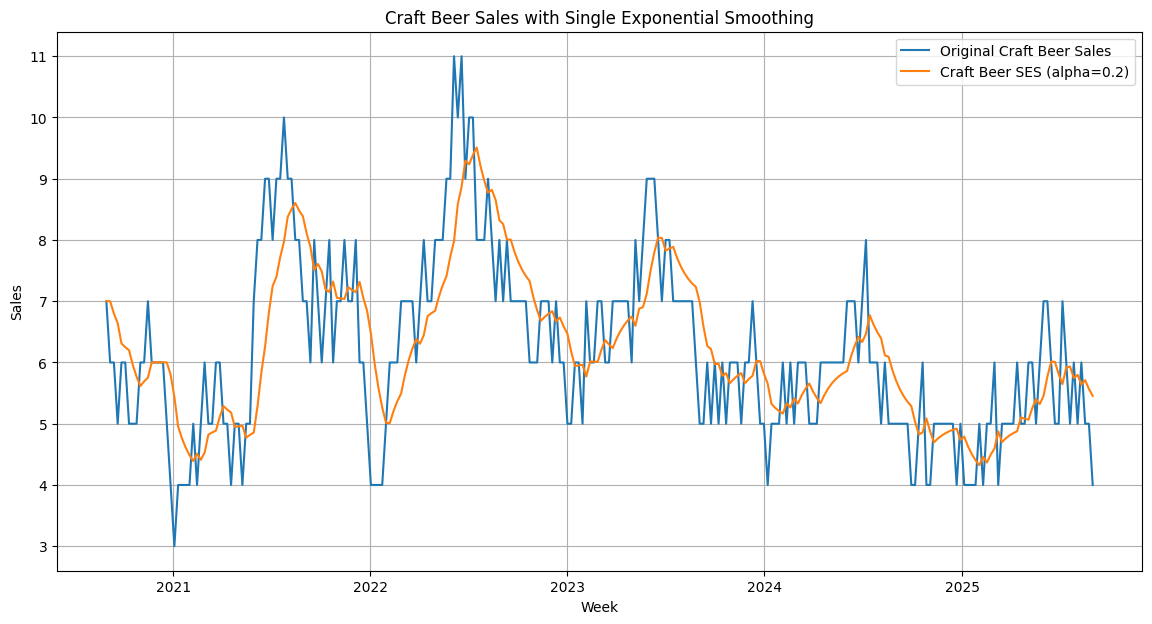

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.pyplot as plt

# Apply Simple Exponential Smoothing to each series
fit1_whisky = SimpleExpSmoothing(df['Whisky: (Canada)']).fit(smoothing_level=0.2)
df['Whisky_SES'] = fit1_whisky.fittedvalues

fit1_whitewine = SimpleExpSmoothing(df['White wine: (Canada)']).fit(smoothing_level=0.2)
df['WhiteWine_SES'] = fit1_whitewine.fittedvalues

fit1_craftbeer = SimpleExpSmoothing(df['Craft Beer: (Canada)']).fit(smoothing_level=0.2)
df['CraftBeer_SES'] = fit1_craftbeer.fittedvalues

# Plot the original data and the smoothed data
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Whisky: (Canada)'], label='Original Whisky Sales')
plt.plot(df.index, df['Whisky_SES'], label='Whisky SES (alpha=0.2)')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Whisky Sales with Single Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['White wine: (Canada)'], label='Original White Wine Sales')
plt.plot(df.index, df['WhiteWine_SES'], label='White Wine SES (alpha=0.2)')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('White Wine Sales with Single Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Craft Beer: (Canada)'], label='Original Craft Beer Sales')
plt.plot(df.index, df['CraftBeer_SES'], label='Craft Beer SES (alpha=0.2)')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Craft Beer Sales with Single Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

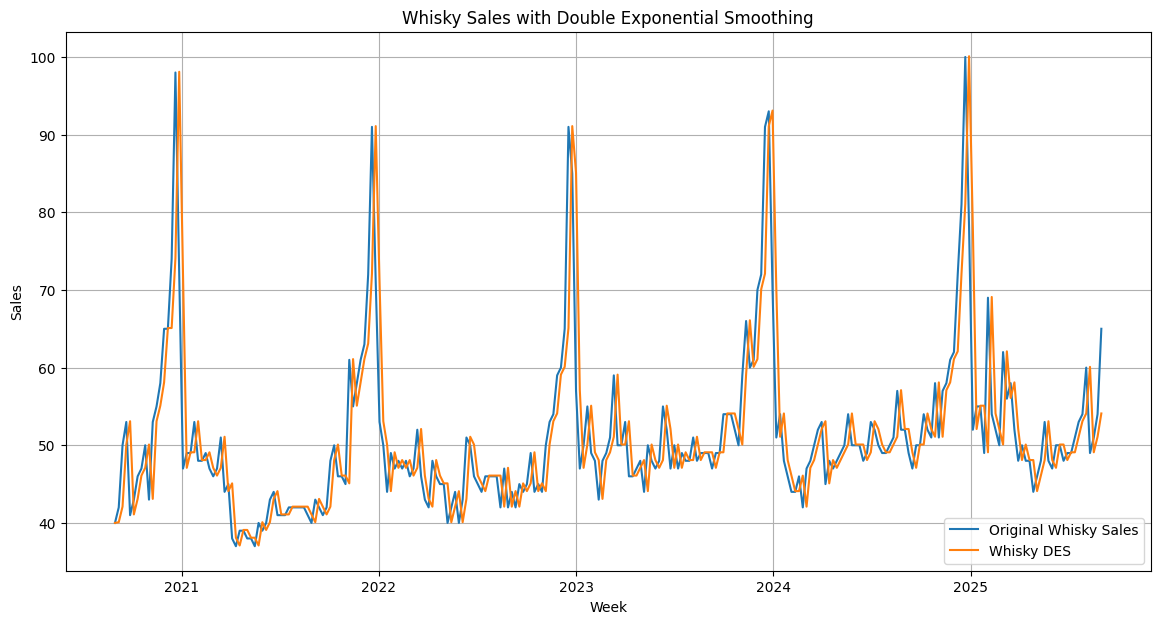

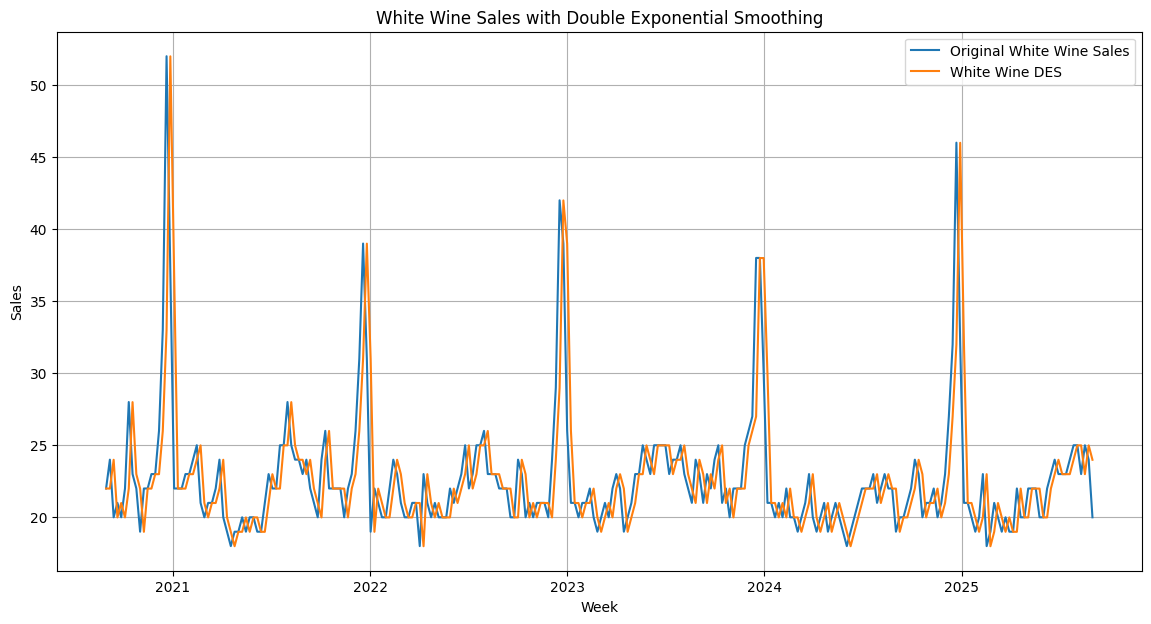

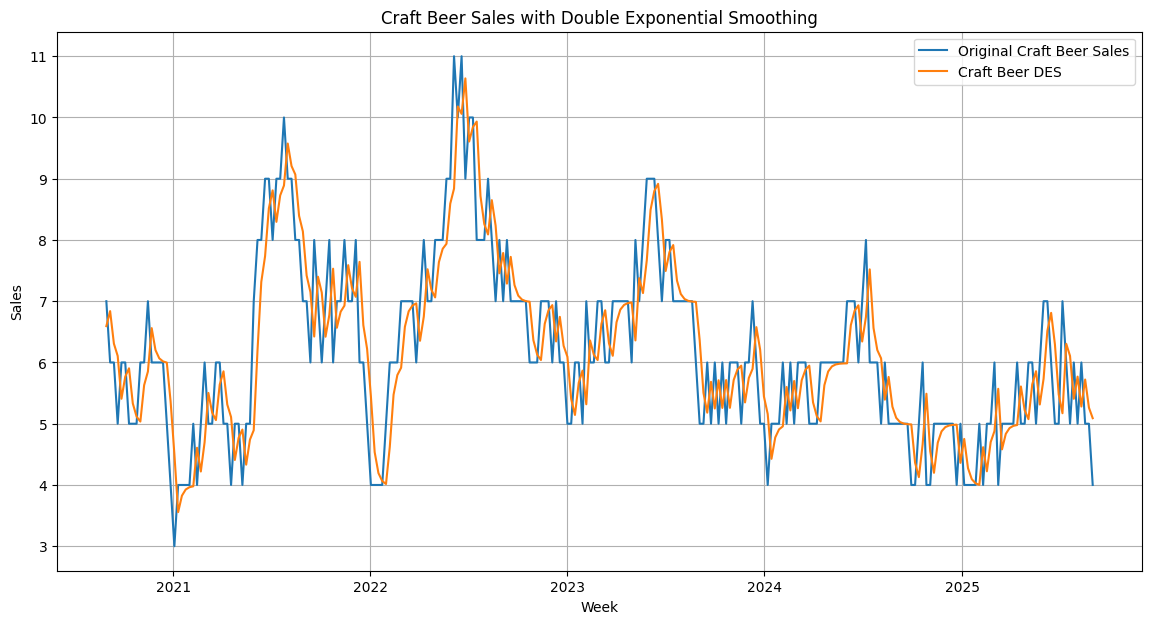

In [ ]:
import matplotlib.pyplot as plt

# Plot for Whisky
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Whisky: (Canada)'], label='Original Whisky Sales')
plt.plot(df.index, df['Whisky_DES'], label='Whisky DES')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Whisky Sales with Double Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

# Plot for White Wine
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['White wine: (Canada)'], label='Original White Wine Sales')
plt.plot(df.index, df['WhiteWine_DES'], label='White Wine DES')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('White Wine Sales with Double Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

# Plot for Craft Beer
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Craft Beer: (Canada)'], label='Original Craft Beer Sales')
plt.plot(df.index, df['CraftBeer_DES'], label='Craft Beer DES')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Craft Beer Sales with Double Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors for Whisky SES
mae_whisky_ses = mean_absolute_error(df['Whisky: (Canada)'].iloc[1:], df['Whisky_SES'].iloc[1:])
mse_whisky_ses = mean_squared_error(df['Whisky: (Canada)'].iloc[1:], df['Whisky_SES'].iloc[1:])
rmse_whisky_ses = np.sqrt(mse_whisky_ses)
mape_whisky_ses = np.mean(np.abs((df['Whisky: (Canada)'].iloc[1:] - df['Whisky_SES'].iloc[1:]) / df['Whisky: (Canada)'].iloc[1:])) * 100

print("Whisky Single Exponential Smoothing Errors:")
print(f"MAE: {mae_whisky_ses:.2f}")
print(f"MSE: {mse_whisky_ses:.2f}")
print(f"RMSE: {rmse_whisky_ses:.2f}")
print(f"MAPE: {mape_whisky_ses:.2f}%")

# Calculate errors for White Wine SES
mae_whitewine_ses = mean_absolute_error(df['White wine: (Canada)'].iloc[1:], df['WhiteWine_SES'].iloc[1:])
mse_whitewine_ses = mean_squared_error(df['White wine: (Canada)'].iloc[1:], df['WhiteWine_SES'].iloc[1:])
rmse_whitewine_ses = np.sqrt(mse_whitewine_ses)
mape_whitewine_ses = np.mean(np.abs((df['White wine: (Canada)'].iloc[1:] - df['WhiteWine_SES'].iloc[1:]) / df['White wine: (Canada)'].iloc[1:])) * 100


print("\nWhite Wine Single Exponential Smoothing Errors:")
print(f"MAE: {mae_whitewine_ses:.2f}")
print(f"MSE: {mse_whitewine_ses:.2f}")
print(f"RMSE: {rmse_whitewine_ses:.2f}")
print(f"MAPE: {mape_whitewine_ses:.2f}%")

# Calculate errors for Craft Beer SES
mae_craftbeer_ses = mean_absolute_error(df['Craft Beer: (Canada)'].iloc[1:], df['CraftBeer_SES'].iloc[1:])
mse_craftbeer_ses = mean_squared_error(df['Craft Beer: (Canada)'].iloc[1:], df['CraftBeer_SES'].iloc[1:])
rmse_craftbeer_ses = np.sqrt(mse_craftbeer_ses)
mape_craftbeer_ses = np.mean(np.abs((df['Craft Beer: (Canada)'].iloc[1:] - df['CraftBeer_SES'].iloc[1:]) / df['Craft Beer: (Canada)'].iloc[1:])) * 100


print("\nCraft Beer Single Exponential Smoothing Errors:")
print(f"MAE: {mae_craftbeer_ses:.2f}")
print(f"MSE: {mse_craftbeer_ses:.2f}")
print(f"RMSE: {rmse_craftbeer_ses:.2f}")
print(f"MAPE: {mape_craftbeer_ses:.2f}%")

Whisky Single Exponential Smoothing Errors:
MAE: 5.56
MSE: 72.50
RMSE: 8.51
MAPE: 10.04%

White Wine Single Exponential Smoothing Errors:
MAE: 2.50
MSE: 16.64
RMSE: 4.08
MAPE: 10.25%

Craft Beer Single Exponential Smoothing Errors:
MAE: 0.77
MSE: 0.92
RMSE: 0.96
MAPE: 13.00%


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors for Whisky DES
mae_whisky_des = mean_absolute_error(df['Whisky: (Canada)'].iloc[2:], df['Whisky_DES'].iloc[2:])
mse_whisky_des = mean_squared_error(df['Whisky: (Canada)'].iloc[2:], df['Whisky_DES'].iloc[2:])
rmse_whisky_des = np.sqrt(mse_whisky_des)
mape_whisky_des = np.mean(np.abs((df['Whisky: (Canada)'].iloc[2:] - df['Whisky_DES'].iloc[2:]) / df['Whisky: (Canada)'].iloc[2:])) * 100

print("Whisky Double Exponential Smoothing Errors:")
print(f"MAE: {mae_whisky_des:.2f}")
print(f"MSE: {mse_whisky_des:.2f}")
print(f"RMSE: {rmse_whisky_des:.2f}")
print(f"MAPE: {mape_whisky_des:.2f}%")

# Calculate errors for White Wine DES
mae_whitewine_des = mean_absolute_error(df['White wine: (Canada)'].iloc[2:], df['WhiteWine_DES'].iloc[2:])
mse_whitewine_des = mean_squared_error(df['White wine: (Canada)'].iloc[2:], df['WhiteWine_DES'].iloc[2:])
rmse_whitewine_des = np.sqrt(mse_whitewine_des)
mape_whitewine_des = np.mean(np.abs((df['White wine: (Canada)'].iloc[2:] - df['WhiteWine_DES'].iloc[2:]) / df['White wine: (Canada)'].iloc[2:])) * 100


print("\nWhite Wine Double Exponential Smoothing Errors:")
print(f"MAE: {mae_whitewine_des:.2f}")
print(f"MSE: {mse_whitewine_des:.2f}")
print(f"RMSE: {rmse_whitewine_des:.2f}")
print(f"MAPE: {mape_whitewine_des:.2f}%")

# Calculate errors for Craft Beer DES
mae_craftbeer_des = mean_absolute_error(df['Craft Beer: (Canada)'].iloc[2:], df['CraftBeer_DES'].iloc[2:])
mse_craftbeer_des = mean_squared_error(df['Craft Beer: (Canada)'].iloc[2:], df['CraftBeer_DES'].iloc[2:])
rmse_craftbeer_des = np.sqrt(mse_craftbeer_des)
mape_craftbeer_des = np.mean(np.abs((df['Craft Beer: (Canada)'].iloc[2:] - df['CraftBeer_DES'].iloc[2:]) / df['Craft Beer: (Canada)'].iloc[2:])) * 100


print("\nCraft Beer Double Exponential Smoothing Errors:")
print(f"MAE: {mae_craftbeer_des:.2f}")
print(f"MSE: {mse_craftbeer_des:.2f}")
print(f"RMSE: {rmse_craftbeer_des:.2f}")
print(f"MAPE: {mape_craftbeer_des:.2f}%")

Whisky Double Exponential Smoothing Errors:
MAE: 4.15
MSE: 45.74
RMSE: 6.76
MAPE: 7.52%

White Wine Double Exponential Smoothing Errors:
MAE: 1.99
MSE: 11.88
RMSE: 3.45
MAPE: 8.12%

Craft Beer Double Exponential Smoothing Errors:
MAE: 0.65
MSE: 0.63
RMSE: 0.79
MAPE: 10.90%


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Apply Triple Exponential Smoothing (Holt-Winters Seasonal Method) to each series
# Using additive trend and seasonal components with a seasonal period of 52 (weekly data)
fit_tes_whisky = ExponentialSmoothing(df['Whisky: (Canada)'], trend='add', seasonal='add', seasonal_periods=52).fit()
df['Whisky_TES'] = fit_tes_whisky.fittedvalues

fit_tes_whitewine = ExponentialSmoothing(df['White wine: (Canada)'], trend='add', seasonal='add', seasonal_periods=52).fit()
df['WhiteWine_TES'] = fit_tes_whitewine.fittedvalues

fit_tes_craftbeer = ExponentialSmoothing(df['Craft Beer: (Canada)'], trend='add', seasonal='add', seasonal_periods=52).fit()
df['CraftBeer_TES'] = fit_tes_craftbeer.fittedvalues

display(df.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


,Whisky: (Canada),White wine: (Canada),Craft Beer: (Canada),Whisky_3Week_MA,WhiteWine_3Week_MA,CraftBeer_3Week_MA,Whisky_7Week_MA,WhiteWine_7Week_MA,CraftBeer_7Week_MA,Whisky_SES,WhiteWine_SES,CraftBeer_SES,Whisky_DES,WhiteWine_DES,CraftBeer_DES,Whisky_TES,WhiteWine_TES,CraftBeer_TES
Week,,,,,,,,,,,,,,,,,,
2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN,40.000,22.000,7.000,40.000090,21.999980,6.593587,42.747505,23.256213,6.681901
2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN,40.000,22.000,7.000,40.095786,21.992338,6.838945,45.159173,22.269717,6.148971
2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN,40.400,22.400,6.800,42.095786,23.992338,6.306819,42.833883,21.500868,6.114430
2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN,42.320,21.920,6.640,50.095786,19.992338,6.106903,45.369142,21.317271,6.266528
2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN,44.456,21.736,6.312,53.095786,20.992338,5.407490,45.203918,20.878463,5.534675


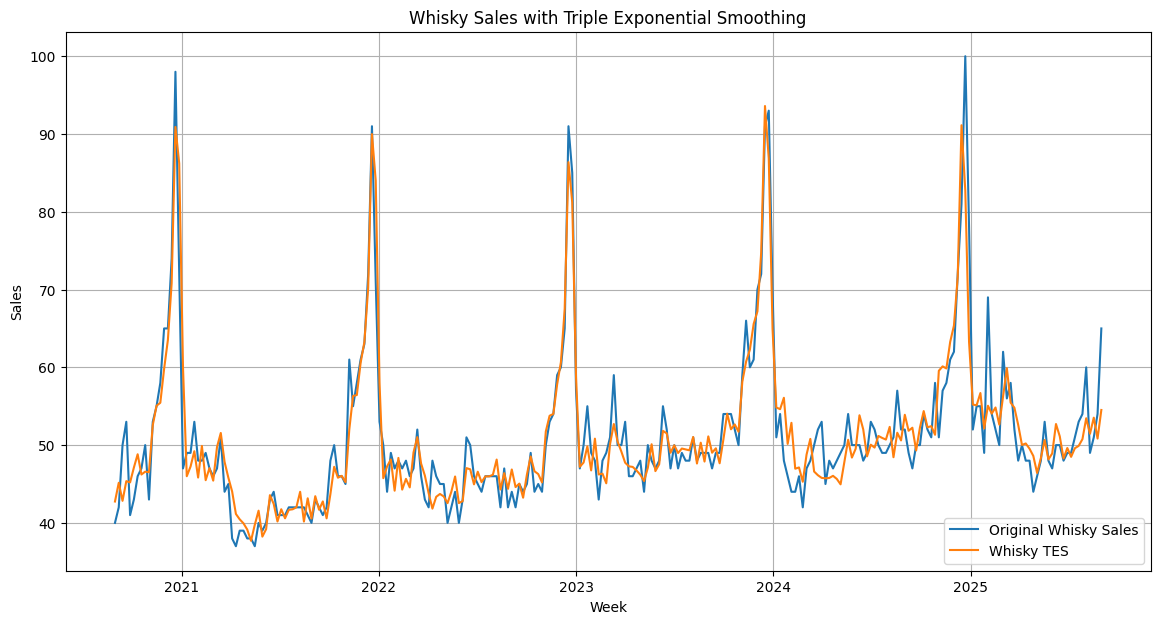

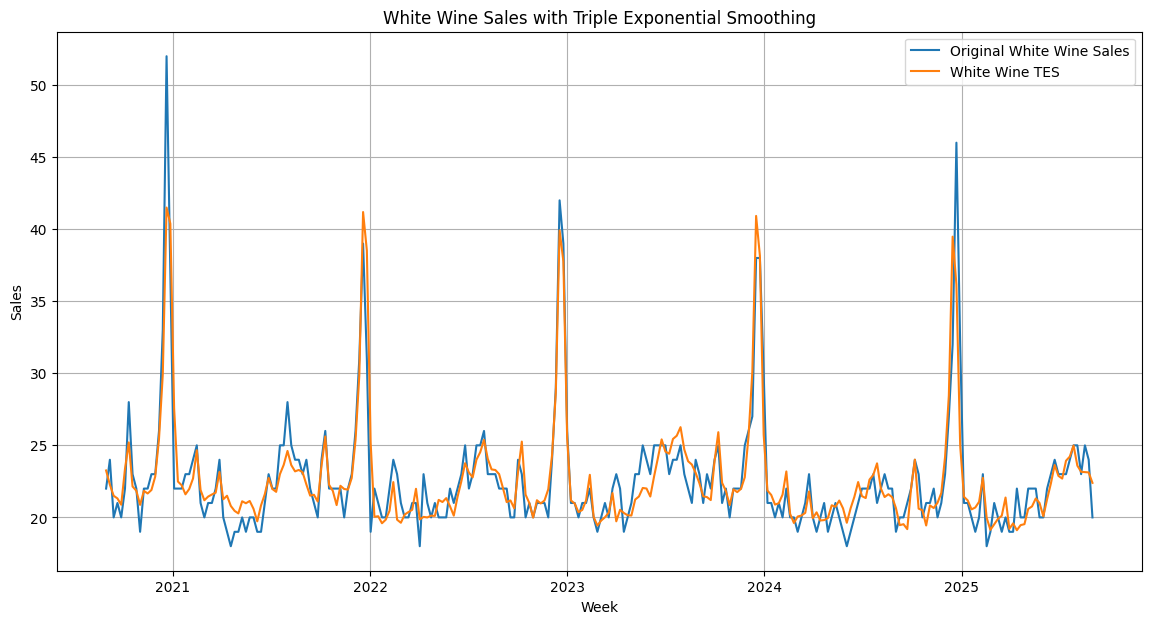

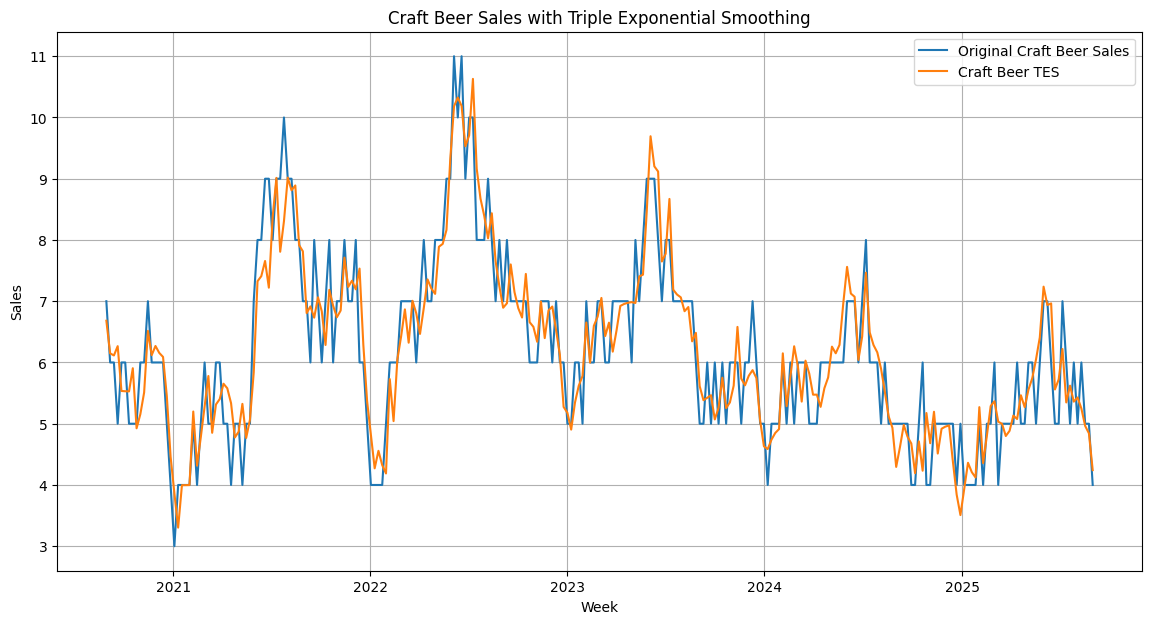

In [ ]:
import matplotlib.pyplot as plt

# Plot for Whisky
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Whisky: (Canada)'], label='Original Whisky Sales')
plt.plot(df.index, df['Whisky_TES'], label='Whisky TES')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Whisky Sales with Triple Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

# Plot for White Wine
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['White wine: (Canada)'], label='Original White Wine Sales')
plt.plot(df.index, df['WhiteWine_TES'], label='White Wine TES')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('White Wine Sales with Triple Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

# Plot for Craft Beer
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Craft Beer: (Canada)'], label='Original Craft Beer Sales')
plt.plot(df.index, df['CraftBeer_TES'], label='Craft Beer TES')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Craft Beer Sales with Triple Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors for Whisky TES
# TES has a startup effect, so we'll drop the first few values (e.g., the first seasonal period)
start_index_tes = 52  # Assuming seasonal_periods=52
mae_whisky_tes = mean_absolute_error(df['Whisky: (Canada)'].iloc[start_index_tes:], df['Whisky_TES'].iloc[start_index_tes:])
mse_whisky_tes = mean_squared_error(df['Whisky: (Canada)'].iloc[start_index_tes:], df['Whisky_TES'].iloc[start_index_tes:])
rmse_whisky_tes = np.sqrt(mse_whisky_tes)
mape_whisky_tes = np.mean(np.abs((df['Whisky: (Canada)'].iloc[start_index_tes:] - df['Whisky_TES'].iloc[start_index_tes:]) / df['Whisky: (Canada)'].iloc[start_index_tes:])) * 100

print("Whisky Triple Exponential Smoothing Errors:")
print(f"MAE: {mae_whisky_tes:.2f}")
print(f"MSE: {mse_whisky_tes:.2f}")
print(f"RMSE: {rmse_whisky_tes:.2f}")
print(f"MAPE: {mape_whisky_tes:.2f}%")

# Calculate errors for White Wine TES
mae_whitewine_tes = mean_absolute_error(df['White wine: (Canada)'].iloc[start_index_tes:], df['WhiteWine_TES'].iloc[start_index_tes:])
mse_whitewine_tes = mean_squared_error(df['White wine: (Canada)'].iloc[start_index_tes:], df['WhiteWine_TES'].iloc[start_index_tes:])
rmse_whitewine_tes = np.sqrt(mse_whitewine_tes)
mape_whitewine_tes = np.mean(np.abs((df['White wine: (Canada)'].iloc[start_index_tes:] - df['WhiteWine_TES'].iloc[start_index_tes:]) / df['White wine: (Canada)'].iloc[start_index_tes:])) * 100

print("\nWhite Wine Triple Exponential Smoothing Errors:")
print(f"MAE: {mae_whitewine_tes:.2f}")
print(f"MSE: {mse_whitewine_tes:.2f}")
print(f"RMSE: {rmse_whitewine_tes:.2f}")
print(f"MAPE: {mape_whitewine_tes:.2f}%")

# Calculate errors for Craft Beer TES
mae_craftbeer_tes = mean_absolute_error(df['Craft Beer: (Canada)'].iloc[start_index_tes:], df['CraftBeer_TES'].iloc[start_index_tes:])
mse_craftbeer_tes = mean_squared_error(df['Craft Beer: (Canada)'].iloc[start_index_tes:], df['CraftBeer_TES'].iloc[start_index_tes:])
rmse_craftbeer_tes = np.sqrt(mse_craftbeer_tes)
mape_craftbeer_tes = np.mean(np.abs((df['Craft Beer: (Canada)'].iloc[start_index_tes:] - df['CraftBeer_TES'].iloc[start_index_tes:]) / df['Craft Beer: (Canada)'].iloc[start_index_tes:])) * 100

print("\nCraft Beer Triple Exponential Smoothing Errors:")
print(f"MAE: {mae_craftbeer_tes:.2f}")
print(f"MSE: {mse_craftbeer_tes:.2f}")
print(f"RMSE: {rmse_craftbeer_tes:.2f}")
print(f"MAPE: {mape_craftbeer_tes:.2f}%")

Whisky Triple Exponential Smoothing Errors:
MAE: 2.54
MSE: 13.16
RMSE: 3.63
MAPE: 4.70%

White Wine Triple Exponential Smoothing Errors:
MAE: 1.10
MSE: 2.88
RMSE: 1.70
MAPE: 4.72%

Craft Beer Triple Exponential Smoothing Errors:
MAE: 0.46
MSE: 0.33
RMSE: 0.57
MAPE: 7.68%


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on Whisky
result_whisky = adfuller(df['Whisky: (Canada)'])
print('ADF Test for Whisky:')
print(f'ADF Statistic: {result_whisky[0]:.4f}')
print(f'p-value: {result_whisky[1]:.4f}')
print('Critical Values:')
for key, value in result_whisky[4].items():
    print(f'\t{key}: {value:.4f}')

# Perform ADF test on White Wine
result_whitewine = adfuller(df['White wine: (Canada)'])
print('\nADF Test for White Wine:')
print(f'ADF Statistic: {result_whitewine[0]:.4f}')
print(f'p-value: {result_whitewine[1]:.4f}')
print('Critical Values:')
for key, value in result_whitewine[4].items():
    print(f'\t{key}: {value:.4f}')

# Perform ADF test on Craft Beer
result_craftbeer = adfuller(df['Craft Beer: (Canada)'])
print('\nADF Test for Craft Beer:')
print(f'ADF Statistic: {result_craftbeer[0]:.4f}')
print(f'p-value: {result_craftbeer[1]:.4f}')
print('Critical Values:')
for key, value in result_craftbeer[4].items():
    print(f'\t{key}: {value:.4f}')

ADF Test for Whisky:
ADF Statistic: -5.0633
p-value: 0.0000
Critical Values:
	1%: -3.4559
	5%: -2.8728
	10%: -2.5728

ADF Test for White Wine:
ADF Statistic: -6.9584
p-value: 0.0000
Critical Values:
	1%: -3.4560
	5%: -2.8728
	10%: -2.5728

ADF Test for Craft Beer:
ADF Statistic: -3.3867
p-value: 0.0114
Critical Values:
	1%: -3.4558
	5%: -2.8727
	10%: -2.5727


H0=the data is non-stationary ; H1= the data is stationary. P-Value < 0.05, hence Accept H1. Data is stationary.


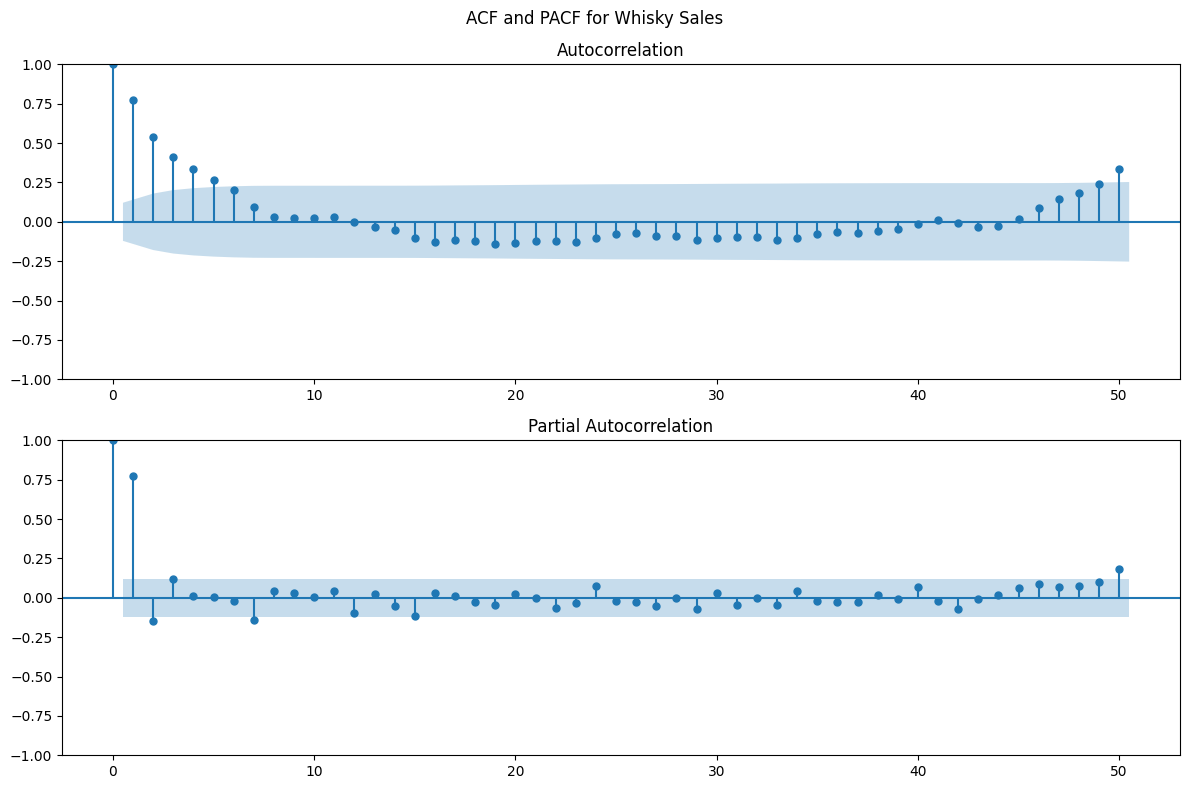

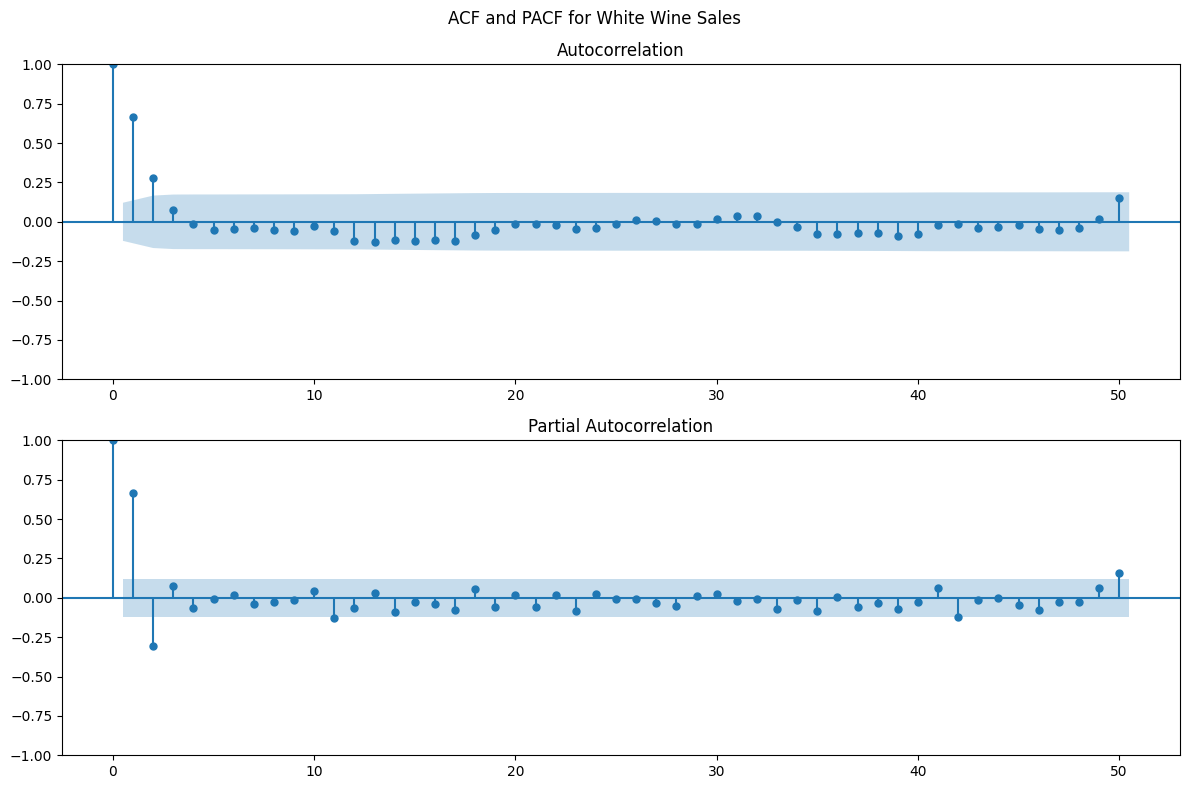

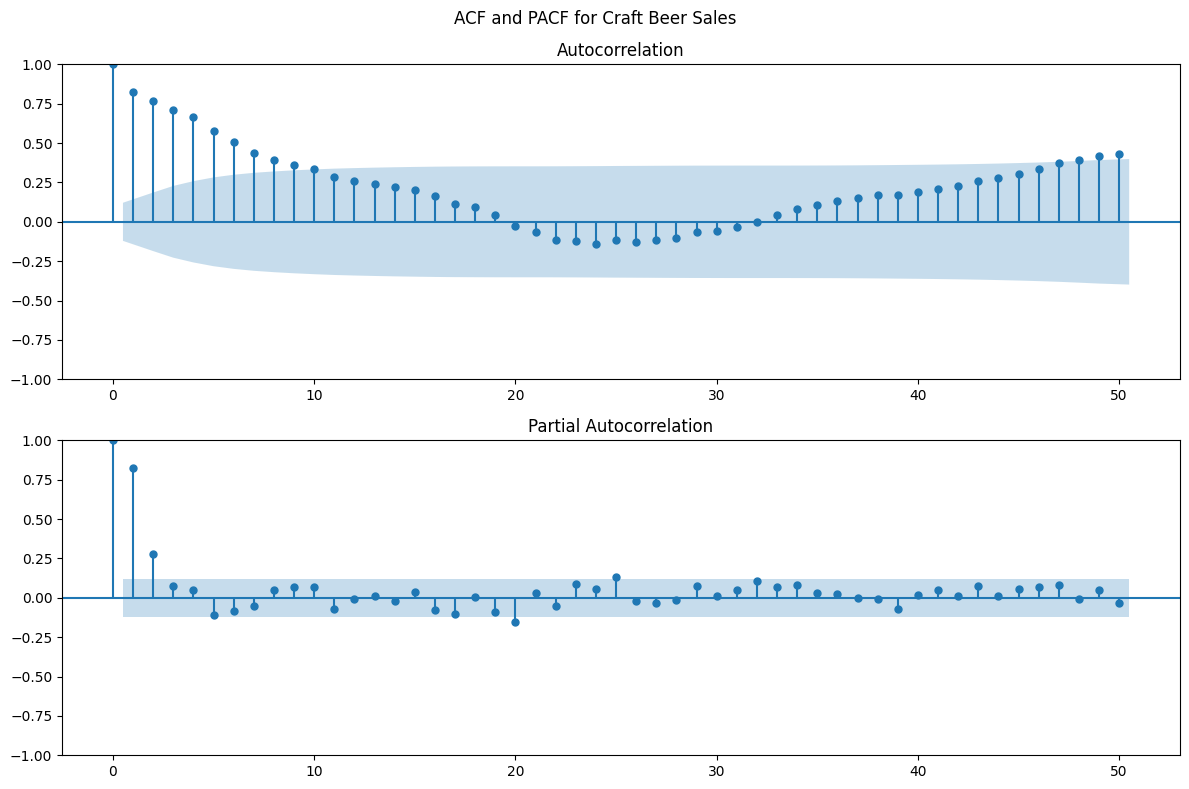

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF for Whisky
plt.figure(figsize=(12, 8))
plot_acf(df['Whisky: (Canada)'], lags=50, ax=plt.subplot(211))
plot_pacf(df['Whisky: (Canada)'], lags=50, ax=plt.subplot(212))
plt.suptitle('ACF and PACF for Whisky Sales')
plt.tight_layout()
plt.show()

# Plot ACF and PACF for White Wine
plt.figure(figsize=(12, 8))
plot_acf(df['White wine: (Canada)'], lags=50, ax=plt.subplot(211))
plot_pacf(df['White wine: (Canada)'], lags=50, ax=plt.subplot(212))
plt.suptitle('ACF and PACF for White Wine Sales')
plt.tight_layout()
plt.show()

# Plot ACF and PACF for Craft Beer
plt.figure(figsize=(12, 8))
plot_acf(df['Craft Beer: (Canada)'], lags=50, ax=plt.subplot(211))
plot_pacf(df['Craft Beer: (Canada)'], lags=50, ax=plt.subplot(212))
plt.suptitle('ACF and PACF for Craft Beer Sales')
plt.tight_layout()
plt.show()

In [ ]:
from pmdarima import auto_arima

# Find the best ARIMA order for Whisky with d=0
arima_model_whisky = auto_arima(df['Whisky: (Canada)'], seasonal=True, stepwise=True,
                                suppress_warnings=True, error_action='ignore', max_p=10,
                                max_q=10, d=0)
print("Best ARIMA order for Whisky (d=0):", arima_model_whisky.order)

# Find the best ARIMA order for White Wine with d=0
arima_model_whitewine = auto_arima(df['White wine: (Canada)'], seasonal=True, stepwise=True,
                                   suppress_warnings=True, error_action='ignore', max_p=10,
                                   max_q=10, d=0)
print("Best ARIMA order for White Wine (d=0):", arima_model_whitewine.order)

# Find the best ARIMA order for Craft Beer with d=0
arima_model_craftbeer = auto_arima(df['Craft Beer: (Canada)'], seasonal=True, stepwise=True,
                                  suppress_warnings=True, error_action='ignore', max_p=10,
                                  max_q=10, d=0)
print("Best ARIMA order for Craft Beer (d=0):", arima_model_craftbeer.order)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Best ARIMA order for Whisky (d=0): (1, 0, 1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Best ARIMA order for White Wine (d=0): (1, 0, 1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Best ARIMA order for Craft Beer (d=0): (1, 0, 1)


# Task
Fit an ARIMA(1,0,1) model to each of the 'Whisky: (Canada)', 'White wine: (Canada)', and 'Craft Beer: (Canada)' time series, calculate error metrics, and analyze model residuals.

## Fit arima models

### Subtask:
Fit an ARIMA(1,0,1) model to each of the 'Whisky: (Canada)', 'White wine: (Canada)', and 'Craft Beer: (Canada)' time series.


**Reasoning**:
Import the necessary class for ARIMA modeling and fit the specified ARIMA(1,0,1) model to each of the time series columns.



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,0,1) to Whisky
arima_model_whisky = ARIMA(df['Whisky: (Canada)'], order=(1, 0, 1))
arima_fit_whisky = arima_model_whisky.fit()
print("Whisky ARIMA(1,0,1) Summary:")
print(arima_fit_whisky.summary())

# Fit ARIMA(1,0,1) to White Wine
arima_model_whitewine = ARIMA(df['White wine: (Canada)'], order=(1, 0, 1))
arima_fit_whitewine = arima_model_whitewine.fit()
print("\nWhite Wine ARIMA(1,0,1) Summary:")
print(arima_fit_whitewine.summary())

# Fit ARIMA(1,0,1) to Craft Beer
arima_model_craftbeer = ARIMA(df['Craft Beer: (Canada)'], order=(1, 0, 1))
arima_fit_craftbeer = arima_model_craftbeer.fit()
print("\nCraft Beer ARIMA(1,0,1) Summary:")
print(arima_fit_craftbeer.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  

Whisky ARIMA(1,0,1) Summary:
                               SARIMAX Results                                
Dep. Variable:       Whisky: (Canada)   No. Observations:                  262
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -853.081
Date:                Sun, 21 Sep 2025   AIC                           1714.163
Time:                        09:46:42   BIC                           1728.436
Sample:                    08-30-2020   HQIC                          1719.900
                         - 08-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.1020      2.206     23.162      0.000      46.778      55.426
ar.L1          0.6788      0.039     17.580      0.000       0.603       0.754
ma.L1          0.2564  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


**Reasoning**:
The models have been fitted successfully. The next step is to calculate the error metrics for each fitted ARIMA model.



In [ ]:
# Calculate errors for Whisky ARIMA(1,0,1)
arima_pred_whisky = arima_fit_whisky.predict()
mae_whisky_arima = mean_absolute_error(df['Whisky: (Canada)'], arima_pred_whisky)
mse_whisky_arima = mean_squared_error(df['Whisky: (Canada)'], arima_pred_whisky)
rmse_whisky_arima = np.sqrt(mse_whisky_arima)
mape_whisky_arima = np.mean(np.abs((df['Whisky: (Canada)'] - arima_pred_whisky) / df['Whisky: (Canada)'])) * 100

print("Whisky ARIMA(1,0,1) Errors:")
print(f"MAE: {mae_whisky_arima:.2f}")
print(f"MSE: {mse_whisky_arima:.2f}")
print(f"RMSE: {rmse_whisky_arima:.2f}")
print(f"MAPE: {mape_whisky_arima:.2f}%")

# Calculate errors for White Wine ARIMA(1,0,1)
arima_pred_whitewine = arima_fit_whitewine.predict()
mae_whitewine_arima = mean_absolute_error(df['White wine: (Canada)'], arima_pred_whitewine)
mse_whitewine_arima = mean_squared_error(df['White wine: (Canada)'], arima_pred_whitewine)
rmse_whitewine_arima = np.sqrt(mse_whitewine_arima)
mape_whitewine_arima = np.mean(np.abs((df['White wine: (Canada)'] - arima_pred_whitewine) / df['White wine: (Canada)'])) * 100

print("\nWhite Wine ARIMA(1,0,1) Errors:")
print(f"MAE: {mae_whitewine_arima:.2f}")
print(f"MSE: {mse_whitewine_arima:.2f}")
print(f"RMSE: {rmse_whitewine_arima:.2f}")
print(f"MAPE: {mape_whitewine_arima:.2f}%")

# Calculate errors for Craft Beer ARIMA(1,0,1)
arima_pred_craftbeer = arima_fit_craftbeer.predict()
mae_craftbeer_arima = mean_absolute_error(df['Craft Beer: (Canada)'], arima_pred_craftbeer)
mse_craftbeer_arima = mean_squared_error(df['Craft Beer: (Canada)'], arima_pred_craftbeer)
rmse_craftbeer_arima = np.sqrt(mse_craftbeer_arima)
mape_craftbeer_arima = np.mean(np.abs((df['Craft Beer: (Canada)'] - arima_pred_craftbeer) / df['Craft Beer: (Canada)'])) * 100

print("\nCraft Beer ARIMA(1,0,1) Errors:")
print(f"MAE: {mae_craftbeer_arima:.2f}")
print(f"MSE: {mse_craftbeer_arima:.2f}")
print(f"RMSE: {rmse_craftbeer_arima:.2f}")
print(f"MAPE: {mape_craftbeer_arima:.2f}%")

Whisky ARIMA(1,0,1) Errors:
MAE: 4.17
MSE: 39.56
RMSE: 6.29
MAPE: 7.62%

White Wine ARIMA(1,0,1) Errors:
MAE: 1.81
MSE: 8.88
RMSE: 2.98
MAPE: 7.41%

Craft Beer ARIMA(1,0,1) Errors:
MAE: 0.64
MSE: 0.61
RMSE: 0.78
MAPE: 10.82%


In [ ]:
print("--- Error Comparison Across Methods ---")

print("\nWhisky Error Comparison:")
print(f"  3-Week MA: MAE={mae_whisky:.2f}, MSE={mse_whisky:.2f}, RMSE={rmse_whisky:.2f}, MAPE={mape_whisky:.2f}%")
print(f"  7-Week MA: MAE={mae_whisky_7:.2f}, MSE={mse_whisky_7:.2f}, RMSE={rmse_whisky_7:.2f}, MAPE={mape_whisky_7:.2f}%")
print(f"  SES: MAE={mae_whisky_ses:.2f}, MSE={mse_whisky_ses:.2f}, RMSE={rmse_whisky_ses:.2f}, MAPE={mape_whisky_ses:.2f}%")
print(f"  DES: MAE={mae_whisky_des:.2f}, MSE={mse_whisky_des:.2f}, RMSE={rmse_whisky_des:.2f}, MAPE={mape_whisky_des:.2f}%")
print(f"  TES: MAE={mae_whisky_tes:.2f}, MSE={mse_whisky_tes:.2f}, RMSE={rmse_whisky_tes:.2f}, MAPE={mape_whisky_tes:.2f}%")
print(f"  ARIMA(1,0,1): MAE={mae_whisky_arima:.2f}, MSE={mse_whisky_arima:.2f}, RMSE={rmse_whisky_arima:.2f}, MAPE={mape_whisky_arima:.2f}%")

print("\nWhite Wine Error Comparison:")
print(f"  3-Week MA: MAE={mae_whitewine:.2f}, MSE={mse_whitewine:.2f}, RMSE={rmse_whitewine:.2f}, MAPE={mape_whitewine:.2f}%")
print(f"  7-Week MA: MAE={mae_whitewine_7:.2f}, MSE={mse_whitewine_7:.2f}, RMSE={rmse_whitewine_7:.2f}, MAPE={mape_whitewine_7:.2f}%")
print(f"  SES: MAE={mae_whitewine_ses:.2f}, MSE={mse_whitewine_ses:.2f}, RMSE={rmse_whitewine_ses:.2f}, MAPE={mape_whitewine_ses:.2f}%")
print(f"  DES: MAE={mae_whitewine_des:.2f}, MSE={mse_whitewine_des:.2f}, RMSE={rmse_whitewine_des:.2f}, MAPE={mape_whitewine_des:.2f}%")
print(f"  TES: MAE={mae_whitewine_tes:.2f}, MSE={mse_whitewine_tes:.2f}, RMSE={rmse_whitewine_tes:.2f}, MAPE={mape_whitewine_tes:.2f}%")
print(f"  ARIMA(1,0,1): MAE={mae_whitewine_arima:.2f}, MSE={mse_whitewine_arima:.2f}, RMSE={rmse_whitewine_arima:.2f}, MAPE={mape_whitewine_arima:.2f}%")

print("\nCraft Beer Error Comparison:")
print(f"  3-Week MA: MAE={mae_craftbeer:.2f}, MSE={mse_craftbeer:.2f}, RMSE={rmse_craftbeer:.2f}, MAPE={mape_craftbeer:.2f}%")
print(f"  7-Week MA: MAE={mae_craftbeer_7:.2f}, MSE={mse_craftbeer_7:.2f}, RMSE={rmse_craftbeer_7:.2f}, MAPE={mape_craftbeer_7:.2f}%")
print(f"  SES: MAE={mae_craftbeer_ses:.2f}, MSE={mse_craftbeer_ses:.2f}, RMSE={rmse_craftbeer_ses:.2f}, MAPE={mape_craftbeer_ses:.2f}%")
print(f"  DES: MAE={mae_craftbeer_des:.2f}, MSE={mse_craftbeer_des:.2f}, RMSE={rmse_craftbeer_des:.2f}, MAPE={mape_craftbeer_des:.2f}%")
print(f"  TES: MAE={mae_craftbeer_tes:.2f}, MSE={mse_craftbeer_tes:.2f}, RMSE={rmse_craftbeer_tes:.2f}, MAPE={mape_craftbeer_tes:.2f}%")
print(f"  ARIMA(1,0,1): MAE={mae_craftbeer_arima:.2f}, MSE={mse_craftbeer_arima:.2f}, RMSE={rmse_craftbeer_arima:.2f}, MAPE={mape_craftbeer_arima:.2f}%")

--- Error Comparison Across Methods ---

Whisky Error Comparison:
  3-Week MA: MAE=3.05, MSE=25.96, RMSE=5.10, MAPE=5.53%
  7-Week MA: MAE=4.84, MSE=58.96, RMSE=7.68, MAPE=8.74%
  SES: MAE=5.56, MSE=72.50, RMSE=8.51, MAPE=10.04%
  DES: MAE=4.15, MSE=45.74, RMSE=6.76, MAPE=7.52%
  TES: MAE=2.54, MSE=13.16, RMSE=3.63, MAPE=4.70%
  ARIMA(1,0,1): MAE=4.17, MSE=39.56, RMSE=6.29, MAPE=7.62%

White Wine Error Comparison:
  3-Week MA: MAE=1.50, MSE=7.08, RMSE=2.66, MAPE=6.19%
  7-Week MA: MAE=2.31, MSE=14.93, RMSE=3.86, MAPE=9.47%
  SES: MAE=2.50, MSE=16.64, RMSE=4.08, MAPE=10.25%
  DES: MAE=1.99, MSE=11.88, RMSE=3.45, MAPE=8.12%
  TES: MAE=1.10, MSE=2.88, RMSE=1.70, MAPE=4.72%
  ARIMA(1,0,1): MAE=1.81, MSE=8.88, RMSE=2.98, MAPE=7.41%

Craft Beer Error Comparison:
  3-Week MA: MAE=0.43, MSE=0.29, RMSE=0.54, MAPE=7.30%
  7-Week MA: MAE=0.65, MSE=0.68, RMSE=0.82, MAPE=11.06%
  SES: MAE=0.77, MSE=0.92, RMSE=0.96, MAPE=13.00%
  DES: MAE=0.65, MSE=0.63, RMSE=0.79, MAPE=10.90%
  TES: MAE=0.46, MSE=0

In [ ]:
# Forecast for the next year (52 weeks) using fitted TES models
forecast_whisky_tes = fit_tes_whisky.forecast(steps=52)
forecast_whitewine_tes = fit_tes_whitewine.forecast(steps=52)

print("Whisky Sales Forecast (Next 52 Weeks) using TES:")
print(forecast_whisky_tes)

print("\nWhite Wine Sales Forecast (Next 52 Weeks) using TES:")
print(forecast_whitewine_tes)

Whisky Sales Forecast (Next 52 Weeks) using TES:
2025-09-07    55.114332
2025-09-14    56.114673
2025-09-21    54.314987
2025-09-28    57.115068
2025-10-05    59.714883
2025-10-12    57.714722
2025-10-19    57.914933
2025-10-26    57.115584
2025-11-02    63.916320
2025-11-09    66.317066
2025-11-16    66.717728
2025-11-23    70.518175
2025-11-30    73.118467
2025-12-07    80.118439
2025-12-14    99.518567
2025-12-21    93.319084
2025-12-28    70.119279
2026-01-04    58.919092
2026-01-11    59.519120
2026-01-18    61.119516
2026-01-25    56.920048
2026-02-01    60.520393
2026-02-08    56.520531
2026-02-15    57.320518
2026-02-22    55.720308
2026-03-01    59.919966
2026-03-08    62.319592
2026-03-15    58.719281
2026-03-22    57.518969
2026-03-29    55.918680
2026-04-05    54.318383
2026-04-12    54.518178
2026-04-19    54.318165
2026-04-26    53.718215
2026-05-03    52.518142
2026-05-10    54.517940
2026-05-17    56.917706
2026-05-24    53.917479
2026-05-31    54.717231
2026-06-07    5

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA(1,0,1,52) model to Craft Beer
sarima_model_craftbeer = SARIMAX(df['Craft Beer: (Canada)'], order=(1, 0, 1), seasonal_order=(1, 0, 1, 52))
sarima_fit_craftbeer = sarima_model_craftbeer.fit()

# Forecast for the next year (52 weeks) using fitted SARIMA model
forecast_craftbeer_sarima = sarima_fit_craftbeer.forecast(steps=52)

print("\nCraft Beer Sales Forecast (Next 52 Weeks) using SARIMA(1,0,1,52):")
print(forecast_craftbeer_sarima)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)



Craft Beer Sales Forecast (Next 52 Weeks) using SARIMA(1,0,1,52):
2025-09-07    4.364171
2025-09-14    4.496030
2025-09-21    4.322452
2025-09-28    4.166653
2025-10-05    4.027453
2025-10-12    4.475045
2025-10-19    4.313661
2025-10-26    4.115051
2025-11-02    4.110031
2025-11-09    4.558475
2025-11-16    4.281689
2025-11-23    4.427933
2025-11-30    4.392088
2025-12-07    4.500508
2025-12-14    4.192895
2025-12-21    3.683649
2025-12-28    3.691007
2026-01-04    3.354408
2026-01-11    3.600951
2026-01-18    3.596460
2026-01-25    3.560994
2026-02-01    4.261090
2026-02-08    3.721150
2026-02-15    4.152467
2026-02-22    4.217801
2026-03-01    4.545599
2026-03-08    3.976061
2026-03-15    4.256442
2026-03-22    4.132265
2026-03-29    4.145366
2026-04-05    4.210316
2026-04-12    4.469438
2026-04-19    4.284636
2026-04-26    4.249753
2026-05-03    4.626760
2026-05-10    4.574825
2026-05-17    4.507297
2026-05-24    4.939883
2026-05-31    5.509744
2026-06-07    5.437196
2026-06-14   

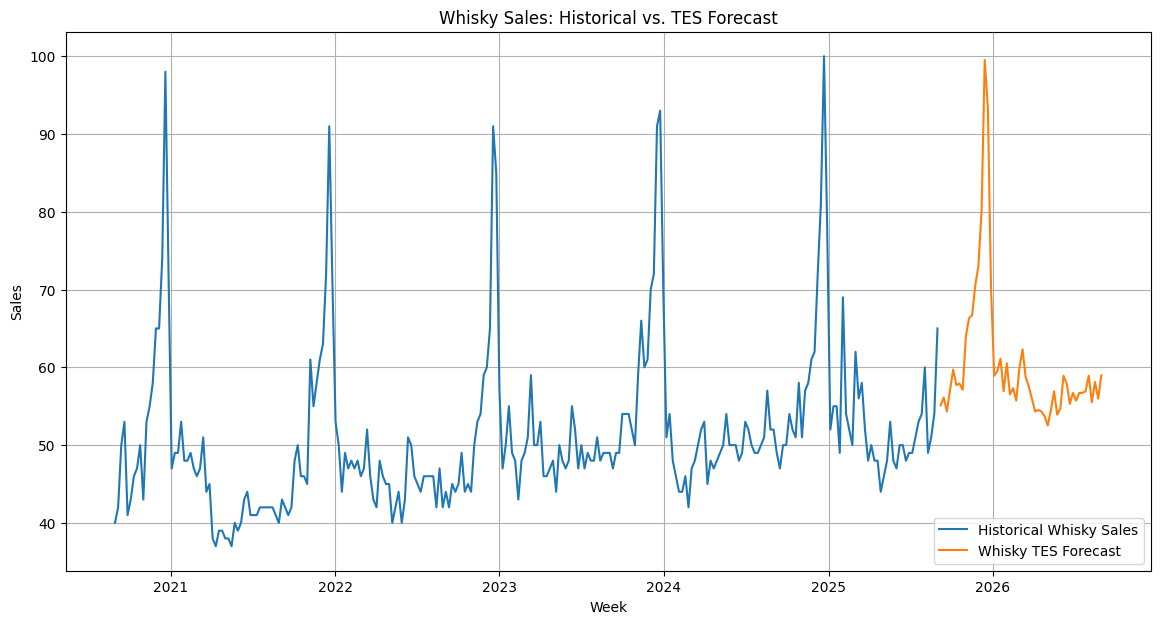

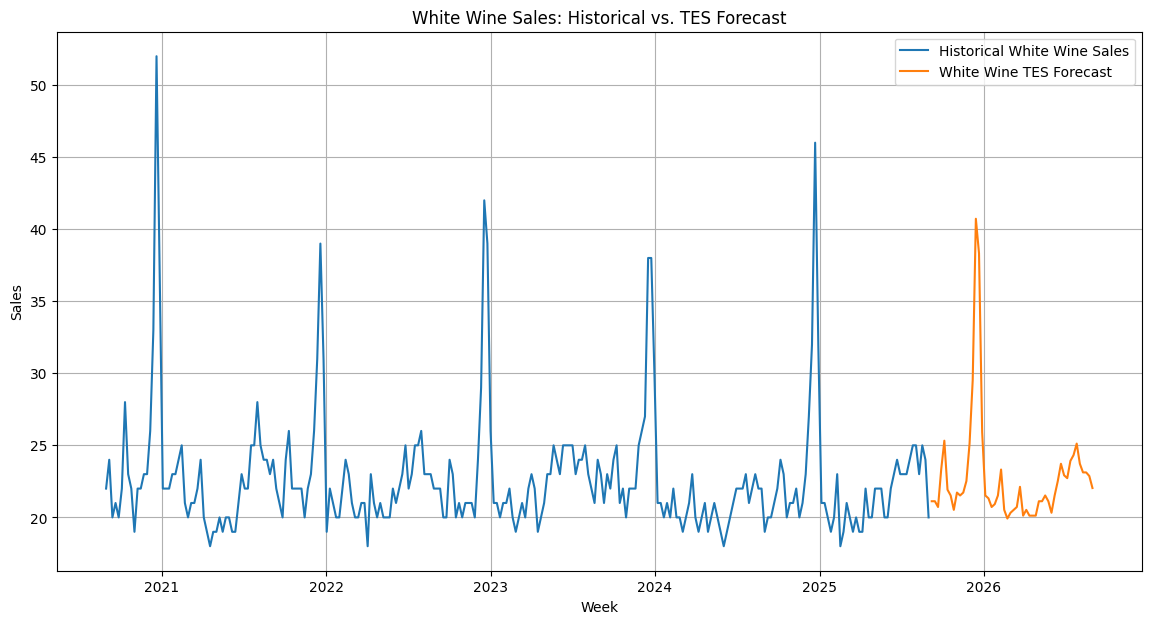

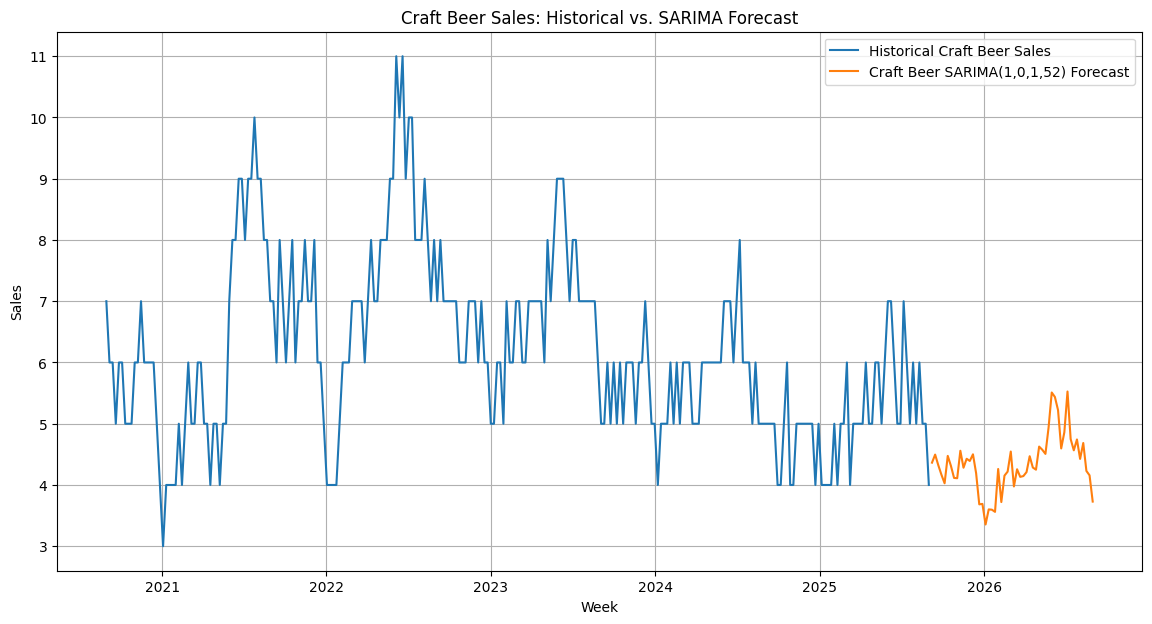

In [ ]:
import matplotlib.pyplot as plt

# Plot historical data and TES forecast for Whisky
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Whisky: (Canada)'], label='Historical Whisky Sales')
plt.plot(forecast_whisky_tes.index, forecast_whisky_tes, label='Whisky TES Forecast')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Whisky Sales: Historical vs. TES Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Plot historical data and TES forecast for White Wine
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['White wine: (Canada)'], label='Historical White Wine Sales')
plt.plot(forecast_whitewine_tes.index, forecast_whitewine_tes, label='White Wine TES Forecast')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('White Wine Sales: Historical vs. TES Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Plot historical data and SARIMA forecast for Craft Beer
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Craft Beer: (Canada)'], label='Historical Craft Beer Sales')
plt.plot(forecast_craftbeer_sarima.index, forecast_craftbeer_sarima, label='Craft Beer SARIMA(1,0,1,52) Forecast')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Craft Beer Sales: Historical vs. SARIMA Forecast')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
Analyze the residuals of the fitted ARIMA models to check for any remaining patterns or autocorrelation, which indicates whether the model has captured all the information in the time series.

